In [20]:
from pathlib import Path
import pandas as pd 
import folium as fl
import osmnx as ox
import matplotlib.pyplot as plt 
import geopandas as gpd

Code block to ensure files are read,created and saved in the right folders

In [17]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory    

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"processed"
figures_directory = project_root/"outputs"/"figures"
maps_directory = project_root/"outputs"/"maps"

for directory in [raw_data_directory,processed_data_directory,figures_directory,maps_directory]:
    directory.mkdir(parents=True,exist_ok=True)

print("Project Root:",project_root)
print("Folders are ready")

Project Root: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis
Folders are ready


In [23]:
ox.settings.use_cache = True
ox.settings.log_console = True

accra_boundary = ox.geocode_to_gdf("Accra, Ghana")
accra_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-0.28427 5.52014, -0.28406 5.51965, ...",-0.284271,5.516926,-0.054857,5.667368,299395220,relation,12803764,5.55711,-0.201238,boundary,administrative,16,0.652835,city,Accra,"Accra, Korle-Klottey Municipal District, Great..."


In [24]:
print("Number of records:", len(accra_boundary))
print("CRS:", accra_boundary.crs)
print("Geometry type:", accra_boundary.geometry.geom_type.iloc[0])

accra_boundary[["display_name", "geometry"]]

Number of records: 1
CRS: epsg:4326
Geometry type: Polygon


,display_name,geometry
0,"Accra, Korle-Klottey Municipal District, Great...","POLYGON ((-0.28427 5.52014, -0.28406 5.51965, ..."


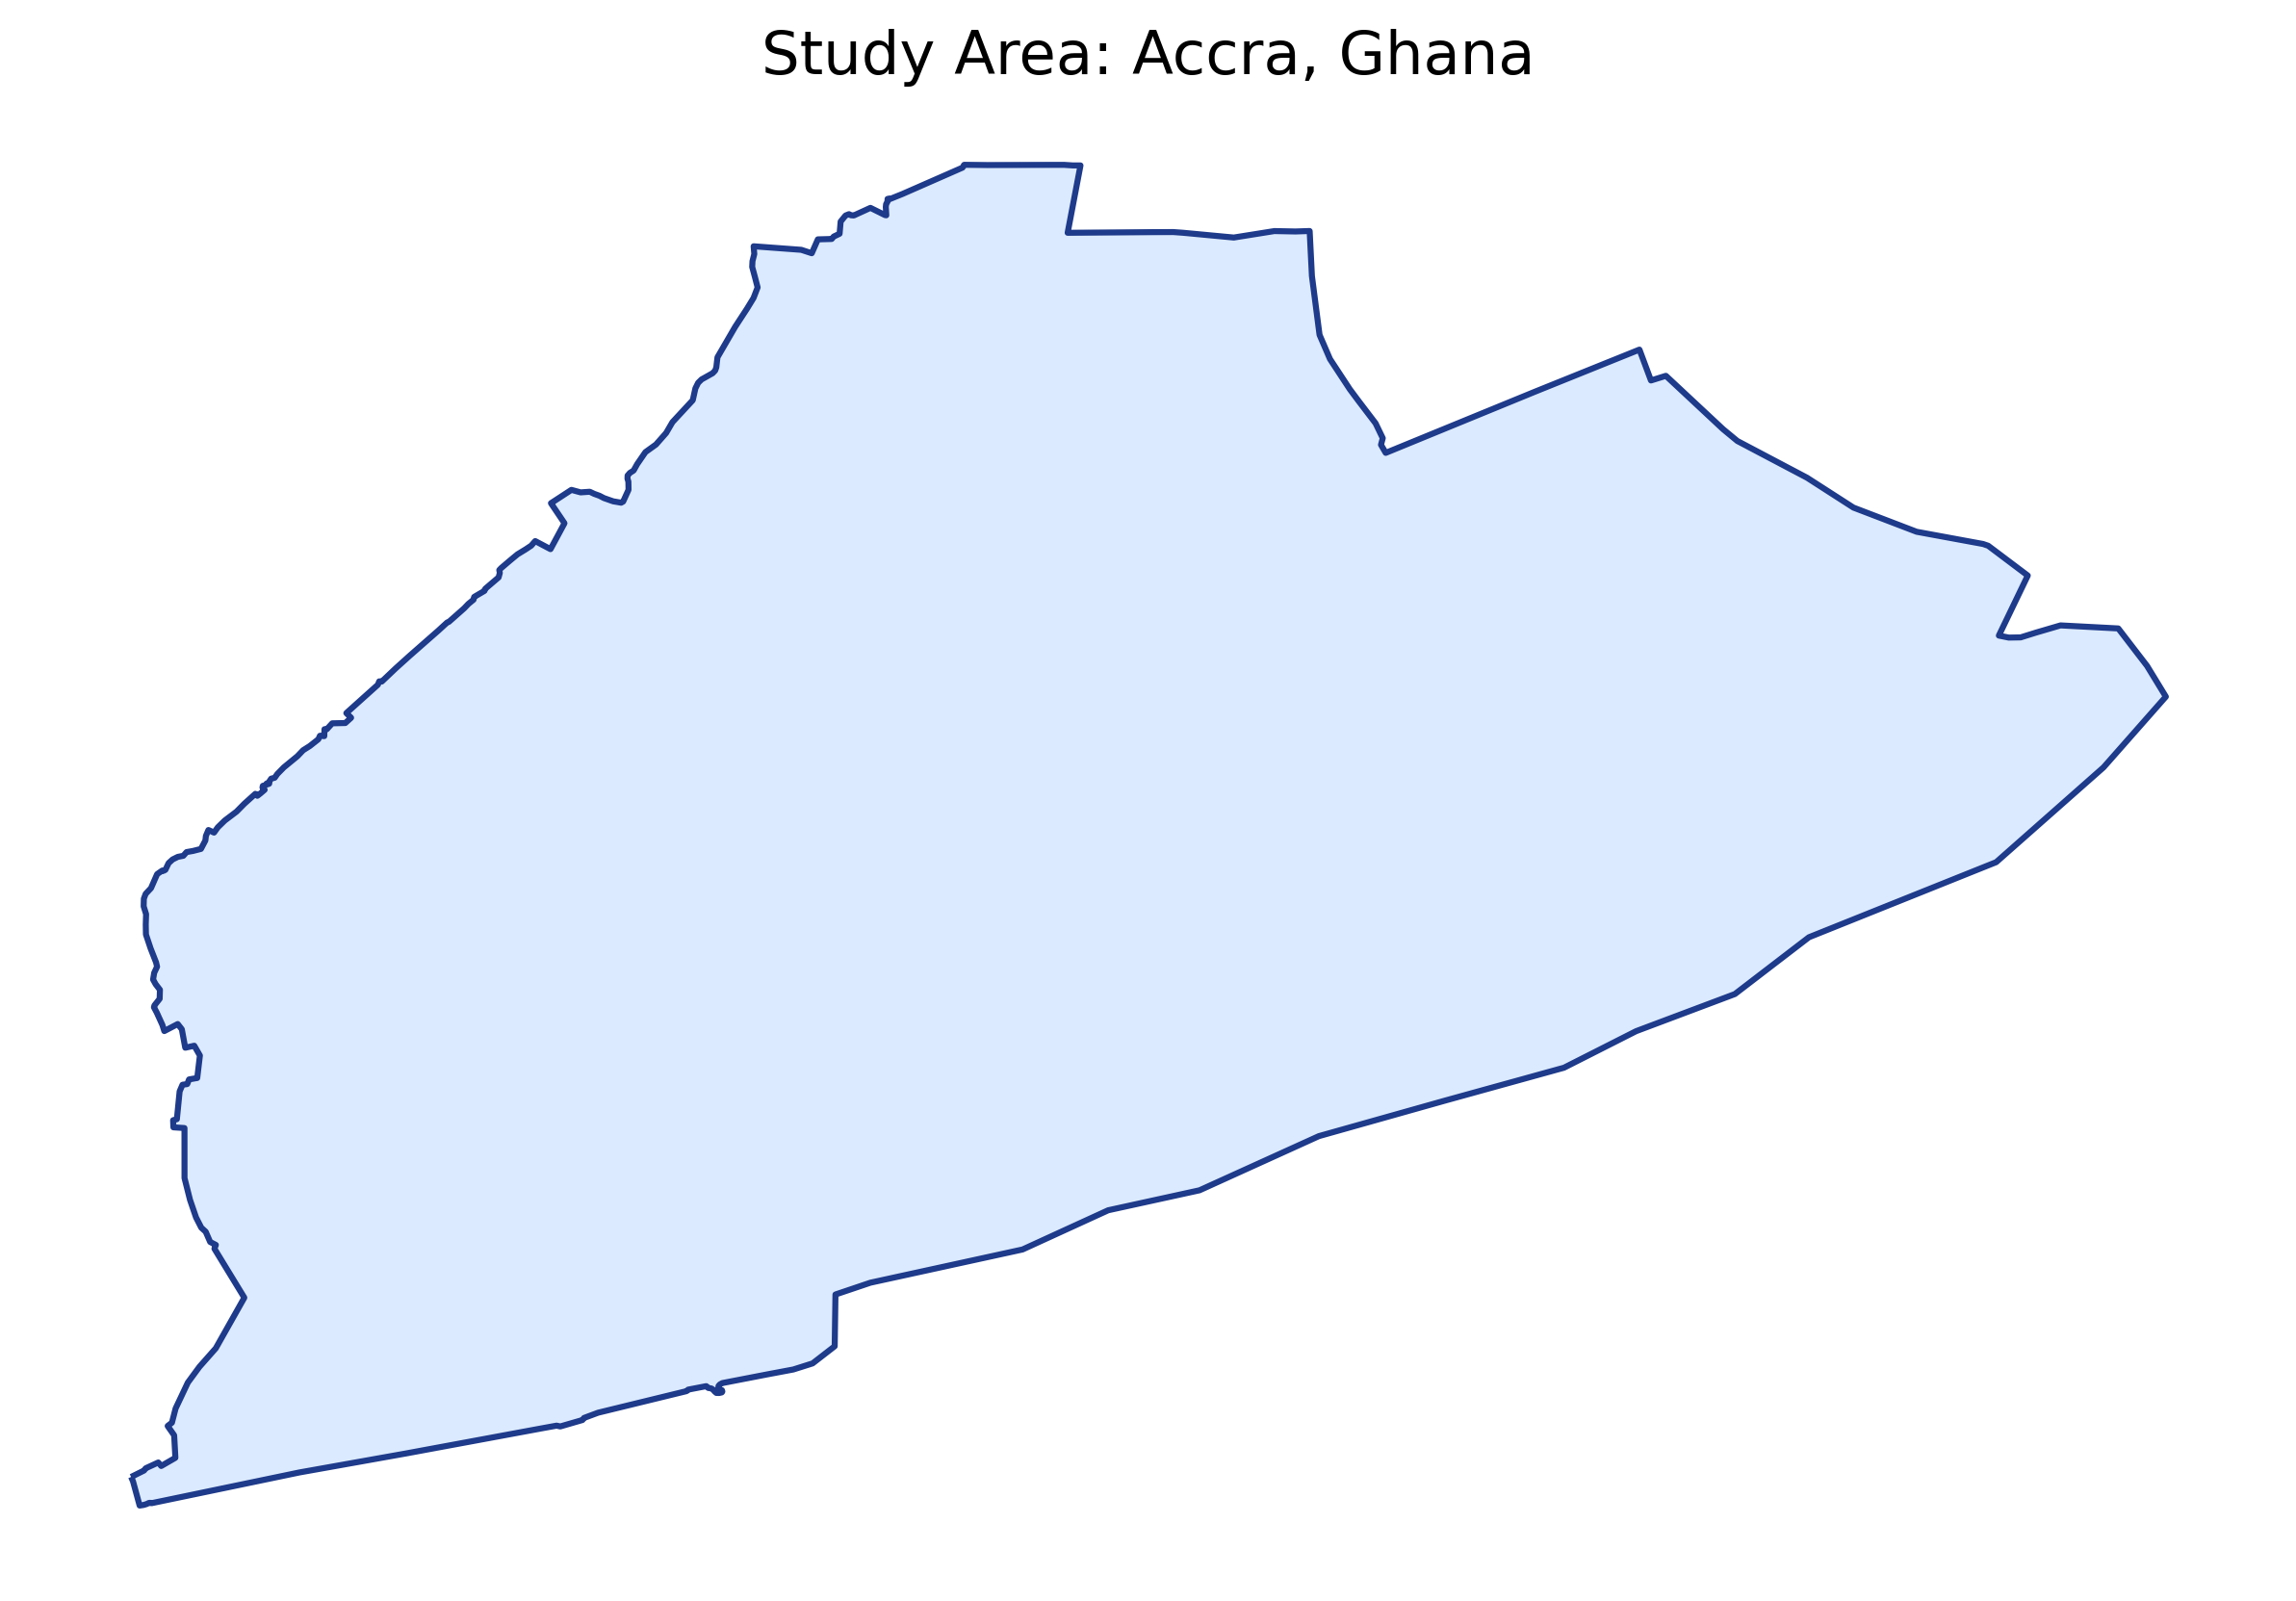

In [25]:
fig,ax = plt.subplots(figsize=(10,10),dpi=300)
accra_boundary.plot(
    ax=ax, facecolor="#dbeafe", edgecolor="#1e3a8a",linewidth= 1.5,
)
ax.set_title("Study Area: Accra, Ghana", fontsize=15)
ax.set_axis_off()
plt.tight_layout
plt.show()

Save the Accra Boundry data on my local Machine

In [26]:
boundry_file_path = raw_data_directory/ "accra_boundary.geojson"

accra_boundary.to_file(boundry_file_path,driver="GeoJSON",)
print("Boundary saved to:",boundry_file_path)

Boundary saved to: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/data/raw/accra_boundary.geojson
